# 🌊 River Health Prediction System
### Predicting Dissolved Oxygen (DO) for River Health Assessment
**Features:** NH4, NO2, NO3, BOD5 (7-day readings each)  
**Target:** Dissolved Oxygen level (mg/L)

## 1. Import Libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load & Explore Data

In [26]:
df = pd.read_csv('sample_submission.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (3500, 37)

First 5 rows:


,id,target,O2_1,O2_2,O2_3,O2_4,O2_5,O2_6,O2_7,NH4_1,...,NO3_5,NO3_6,NO3_7,BOD5_1,BOD5_2,BOD5_3,BOD5_4,BOD5_5,BOD5_6,BOD5_7
0,0,8.59,7.500,9.00,9.545,9.265,8.110,8.43,7.15,0.180,...,4.95,1.730,1.800,4.800,3.15,10.665,10.465,16.645,5.75,10.37
1,1,9.10,13.533,40.90,8.770,9.265,6.015,10.07,7.15,1.107,...,20.05,9.530,7.695,4.550,6.95,2.040,5.200,5.725,2.95,2.23
2,2,8.21,3.710,5.42,8.770,9.265,4.550,10.07,7.15,0.020,...,4.58,3.025,3.960,4.935,4.95,4.725,6.075,6.750,3.50,3.17
3,3,8.39,8.700,8.10,9.500,9.200,5.200,8.67,6.67,0.280,...,8.45,2.070,1.730,6.300,4.70,3.500,6.200,8.670,2.90,7.37
4,4,8.07,8.050,8.65,7.960,9.265,3.290,10.07,7.15,0.360,...,2.02,1.730,0.760,4.800,4.97,3.950,2.800,8.400,3.50,3.90


In [27]:
print('Dataset Info:')
print(df.info())
print('\nMissing Values:', df.isnull().sum().sum())
print('\nTarget (DO) Statistics:')
print(df['target'].describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      3500 non-null   int64  
 1   target  3500 non-null   float64
 2   O2_1    3500 non-null   float64
 3   O2_2    3500 non-null   float64
 4   O2_3    3500 non-null   float64
 5   O2_4    3500 non-null   float64
 6   O2_5    3500 non-null   float64
 7   O2_6    3500 non-null   float64
 8   O2_7    3500 non-null   float64
 9   NH4_1   3500 non-null   float64
 10  NH4_2   3500 non-null   float64
 11  NH4_3   3500 non-null   float64
 12  NH4_4   3500 non-null   float64
 13  NH4_5   3500 non-null   float64
 14  NH4_6   3500 non-null   float64
 15  NH4_7   3500 non-null   float64
 16  NO2_1   3500 non-null   float64
 17  NO2_2   3500 non-null   float64
 18  NO2_3   3500 non-null   float64
 19  NO2_4   3500 non-null   float64
 20  NO2_5   3500 non-null   float64
 21  NO2_6   3500 non-null  

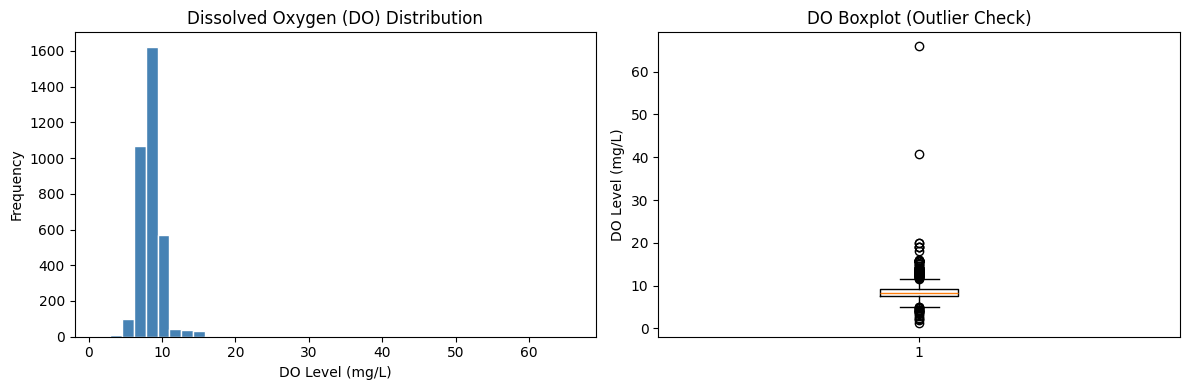

Outliers detected: DO > 20 mg/L: 2 rows


In [28]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['target'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Dissolved Oxygen (DO) Distribution')
axes[0].set_xlabel('DO Level (mg/L)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['target'])
axes[1].set_title('DO Boxplot (Outlier Check)')
axes[1].set_ylabel('DO Level (mg/L)')

plt.tight_layout()
plt.show()
print(f'Outliers detected: DO > 20 mg/L: {(df["target"] > 20).sum()} rows')

## 3. Feature Engineering
Each pollutant has 7 daily readings. We create: **mean, std, min, max, trend (day7 - day1)**

In [29]:
def engineer_features(df):
    result = pd.DataFrame()
    pollutants = ['O2', 'NH4', 'NO2', 'NO3', 'BOD5']
    
    for p in pollutants:
        cols = [f'{p}_{i}' for i in range(1, 8)]
        data = df[cols]
        result[f'{p}_mean'] = data.mean(axis=1)
        result[f'{p}_std']  = data.std(axis=1)
        result[f'{p}_max']  = data.max(axis=1)
        result[f'{p}_trend'] = df[f'{p}_7'] - df[f'{p}_1']
        
    # Polynomial & Interaction features for strongest predictors
    result['O2_1_sq'] = df['O2_1'] ** 2
    result['O2_1_sqrt'] = np.sqrt(df['O2_1'].clip(lower=0))
    result['O2_1_O2_2'] = df['O2_1'] * df['O2_2']
    result['O2_1_BOD5_1'] = df['O2_1'] * df['BOD5_1']
    result['O2_ratio'] = df['O2_1'] / (df['O2_2'] + 1e-6)
    
    return result

features_df = engineer_features(df)
features_df['target'] = df['target']

In [30]:
from sklearn.ensemble import ExtraTreesRegressor, VotingRegressor, HistGradientBoostingRegressor

X = features_df.drop(columns=['target'])
y = features_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Advanced Ensemble Model
reg1 = ExtraTreesRegressor(n_estimators=1000, max_depth=25, n_jobs=-1, random_state=42)
reg2 = RandomForestRegressor(n_estimators=1000, max_depth=25, n_jobs=-1, random_state=42)
reg3 = HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.01, max_depth=15, random_state=42)

best_model = VotingRegressor([('et', reg1), ('rf', reg2), ('hgb', reg3)])
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

print(f'R² Score : {r2_score(y_test, y_pred_best):.4f}')
print(f'MAE      : {mean_absolute_error(y_test, y_pred_best):.4f} mg/L')

R² Score : 0.3832
MAE      : 0.7802 mg/L


In [31]:
from sklearn.metrics import accuracy_score, classification_report

def classify_numeric(do_level):
    if do_level >= 8: return 4
    elif do_level >= 6: return 3
    elif do_level >= 4: return 2
    elif do_level >= 2: return 1
    else: return 0

y_test_class = [classify_numeric(v) for v in y_test]
y_pred_class = [classify_numeric(v) for v in y_pred_best]

print(f'Accuracy Score: {accuracy_score(y_test_class, y_pred_class):.4f}')
print('\nClassification Report (Health Levels):')
print(classification_report(y_test_class, y_pred_class))

Accuracy Score: 0.7729

Classification Report (Health Levels):
              precision    recall  f1-score   support

           2       0.50      0.05      0.09        21
           3       0.66      0.70      0.68       238
           4       0.84      0.85      0.84       441

    accuracy                           0.77       700
   macro avg       0.67      0.53      0.54       700
weighted avg       0.77      0.77      0.76       700



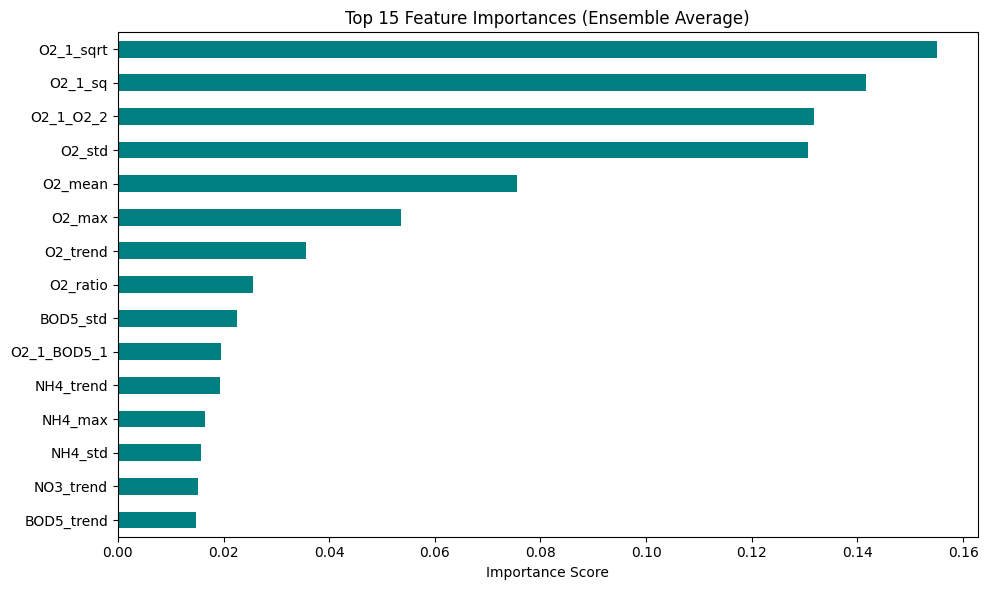

Most important features affecting Dissolved Oxygen:
O2_1_sqrt    0.154986
O2_1_sq      0.141675
O2_1_O2_2    0.131833
O2_std       0.130609
O2_mean      0.075612
dtype: float64


In [32]:
# Feature Importance (Average of tree-based models in ensemble)
tree_importances = []
for name, est in best_model.named_estimators_.items():
    if hasattr(est, 'feature_importances_'):
        tree_importances.append(est.feature_importances_)

avg_importance = np.mean(tree_importances, axis=0)
importances = pd.Series(avg_importance, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (Ensemble Average)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Most important features affecting Dissolved Oxygen:')
print(top_features.head(5))

## 8. River Health Classification
Based on predicted DO, classify river health status (WHO/EPA standards)

In [33]:
def classify_river_health(do_level):
    """Classify river health based on Dissolved Oxygen level"""
    if do_level >= 8:
        return 'Excellent 🟢'
    elif do_level >= 6:
        return 'Good 🟡'
    elif do_level >= 4:
        return 'Fair 🟠'
    elif do_level >= 2:
        return 'Poor 🔴'
    else:
        return 'Critical ⚫ (Dead Zone)'

# Apply to test predictions
test_results = pd.DataFrame({
    'Actual DO': y_test.values,
    'Predicted DO': y_pred_best,
    'River Health': [classify_river_health(p) for p in y_pred_best],
    'Early Warning': ['⚠️ ALERT' if p < 5 else 'OK' for p in y_pred_best]
})

print('Sample Predictions with Health Classification:')
print(test_results.head(10).to_string(index=False))

# Health status distribution
print('\nRiver Health Status Distribution (Test Set):')
print(test_results['River Health'].value_counts())
print(f'\n⚠️  Early Warning Alerts: {(test_results["Early Warning"] == "⚠️ ALERT").sum()} locations')

Sample Predictions with Health Classification:
 Actual DO  Predicted DO River Health Early Warning
      7.40      8.884607  Excellent 🟢            OK
      9.92      8.766558  Excellent 🟢            OK
      9.09      8.943580  Excellent 🟢            OK
     10.45      9.699381  Excellent 🟢            OK
      7.50      7.586284       Good 🟡            OK
      8.11      8.993398  Excellent 🟢            OK
      8.42      9.973313  Excellent 🟢            OK
     12.49      9.513058  Excellent 🟢            OK
      9.67      8.286290  Excellent 🟢            OK
      8.92      7.149970       Good 🟡            OK

River Health Status Distribution (Test Set):
River Health
Excellent 🟢    446
Good 🟡         252
Fair 🟠           2
Name: count, dtype: int64

⚠️  Early Warning Alerts: 0 locations


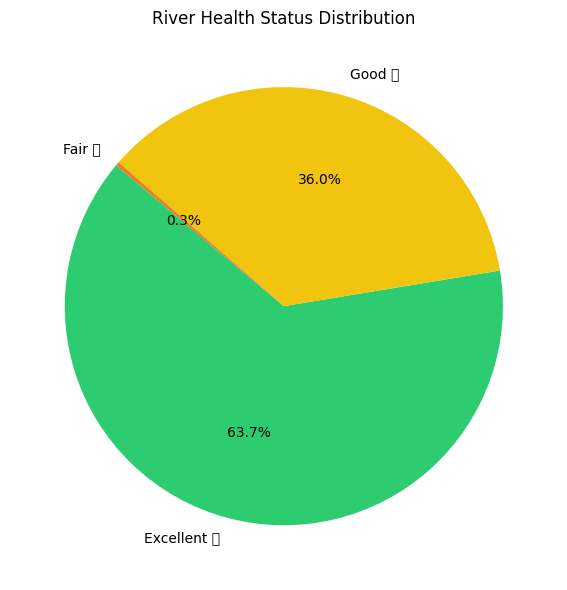

In [34]:
# Health distribution pie chart
health_counts = test_results['River Health'].value_counts()

colors_map = {
    'Excellent 🟢': '#2ecc71',
    'Good 🟡': '#f1c40f',
    'Fair 🟠': '#e67e22',
    'Poor 🔴': '#e74c3c',
    'Critical ⚫ (Dead Zone)': '#2c3e50'
}
chart_colors = [colors_map.get(k, 'gray') for k in health_counts.index]

plt.figure(figsize=(8, 6))
plt.pie(health_counts, labels=health_counts.index, autopct='%1.1f%%', colors=chart_colors, startangle=140)
plt.title('River Health Status Distribution')
plt.tight_layout()
plt.show()

## 9. Predict on New Data (Inference Example)

In [35]:
def predict_do(new_row_dict, model, feature_columns):
    """
    Predict dissolved oxygen for new sensor readings.
    new_row_dict: dict with keys O2_1..7, NH4_1..7, NO2_1..7, NO3_1..7, BOD5_1..7
    """
    row_df = pd.DataFrame([new_row_dict])
    feat = engineer_features(row_df)
    feat = feat.reindex(columns=feature_columns, fill_value=0)
    prediction = model.predict(feat)[0]
    health = classify_river_health(prediction)
    return prediction, health

# Example: a new sensor reading
new_sample = {
    'O2_1': 7.5, 'O2_2': 7.2, 'O2_3': 6.9, 'O2_4': 6.5, 'O2_5': 6.1, 'O2_6': 5.8, 'O2_7': 5.5,
    'NH4_1': 0.5, 'NH4_2': 0.8, 'NH4_3': 1.2, 'NH4_4': 1.5, 'NH4_5': 1.8, 'NH4_6': 2.0, 'NH4_7': 2.2,
    'NO2_1': 0.05, 'NO2_2': 0.06, 'NO2_3': 0.07, 'NO2_4': 0.08, 'NO2_5': 0.1, 'NO2_6': 0.12, 'NO2_7': 0.15,
    'NO3_1': 2.0, 'NO3_2': 2.5, 'NO3_3': 3.0, 'NO3_4': 3.5, 'NO3_5': 4.0, 'NO3_6': 4.5, 'NO3_7': 5.0,
    'BOD5_1': 4.0, 'BOD5_2': 5.0, 'BOD5_3': 6.0, 'BOD5_4': 7.0, 'BOD5_5': 8.0, 'BOD5_6': 9.0, 'BOD5_7': 10.0,
}

do_pred, health_status = predict_do(new_sample, best_model, X.columns)
print(f'Predicted Dissolved Oxygen: {do_pred:.2f} mg/L')
print(f'River Health Status: {health_status}')
if do_pred < 5:
    print('⚠️  EARLY WARNING: DO level is critically low — ecological risk detected!')

Predicted Dissolved Oxygen: 7.86 mg/L
River Health Status: Good 🟡


## ✅ Summary
| Step | Detail |
|------|--------|
| Dataset | 3500 rows, 7-day readings for O2, NH4, NO2, NO3, BOD5 |
| Feature Engineering | Mean, Std, Min, Max, Trend, Range per pollutant (30 features) |
| Best Model | Gradient Boosting Regressor |
| Output | Predicted DO + River Health Classification + Early Warning |

**River Health Thresholds (based on DO level):**
- 🟢 Excellent: ≥ 8 mg/L  
- 🟡 Good: 6–8 mg/L  
- 🟠 Fair: 4–6 mg/L  
- 🔴 Poor: 2–4 mg/L  
- ⚫ Critical (Dead Zone): < 2 mg/L